# ZINC Oracle Study

This notebook isolates the effect of the feasibility oracle on an already-trained ZINC generator.

It assumes:

- a trained generator snapshot has been uploaded or copied locally,
- a cached ZINC graph corpus already exists under `notebooks/datasets/zinc`,
- you want side-by-side oracle-off versus oracle-on comparisons under the same notebook workflow.


In [1]:
#raise RuntimeError("Run notebooks/init.ipynb first for notebook environment setup.")

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.core.display import HTML

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook

globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo import (
    collect_oracle_trace_rows,
    oracle_trace_frame,
    parse_oracle_trace_title,
    show_molecules,
)
from conditional_node_field_graph_generator.extensions.demo.pipeline import prepare_zinc_data_split
from abstractgraph_graphicalizer.chem import (
    draw_molecules,
)
from conditional_node_field_graph_generator.persistence import load_graph_generator


PyTorch version: 2.10.0+cpu
CUDA available: False
Enabling RDKit 2025.09.6 jupyter extensions


## Helpers

The helpers below keep the oracle comparison logic explicit and reproducible.


In [3]:
def _set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))


def _fmt_score(value):
    return '-inf' if value is None else f'{value:.3f}'


def _print_oracle_trace_rows(trace_rows):
    for row in trace_rows:
        print(
            f"Oracle {row['phase']} iteration={row['iteration']} "
            f"violating_node_sets={row['violating_node_sets']} "
            f"violating_edge_sets={row['violating_edge_sets']} "
            f"new_structural_cuts={row['new_structural_cuts']} "
            f"accepted_structural_cuts={row['accepted_structural_cuts']}"
        )
        if row.get('log_total') is not None:
            print(
                '  proposal log-score: '
                f"total={row['log_total']:.3f} | "
                f"edge={0.0 if row.get('log_edge') is None else row['log_edge']:.3f} | "
                f"node={0.0 if row.get('log_node') is None else row['log_node']:.3f} | "
                f"edge_label={0.0 if row.get('log_edge_label') is None else row['log_edge_label']:.3f}"
            )
            print(
                '  running best: '
                f"best_total={_fmt_score(row.get('best_log_total'))} | "
                f"best_feasible={_fmt_score(row.get('best_feasible_log_total'))}"
            )


def show_oracle_decode_trace(
    graph_generator,
    seed_graph,
    *,
    feasibility_oracle_candidates_per_attempt=2,
    seed=7,
):
    show_molecules([seed_graph], n=1, title='Conditioning molecule')
    if getattr(graph_generator, 'feasibility_estimator', None) is None:
        print('Feasibility estimator unavailable; oracle trace cannot be shown.')
        return {'conditioning_graph': seed_graph, 'oracle_on': [], 'trace': []}
    if graph_generator.graph_decoder.verbose < 4 or graph_generator.graph_decoder.n_jobs != 1:
        print('Set DECODER_VERBOSE >= 4 and DECODER_N_JOBS = 1 to display inline oracle phases.')

    print(
        'Oracle ON trace for the same conditioning graph '
        f'(candidate budget={feasibility_oracle_candidates_per_attempt}, '
        f'max_oracle_iterations={graph_generator.max_oracle_iterations}).'
    )
    print('Feasibility filtering is forced OFF here so only one decode trajectory is shown.')
    print('Rows are emitted separately for the joint-label phase, structural edge-set phase, and feasibility checks.')
    _set_all_seeds(seed)
    with collect_oracle_trace_rows() as trace_rows:
        oracle_on = graph_generator.sample_conditioned_on_random(
            [seed_graph],
            n_samples=1,
            apply_feasibility_filtering=False,
            feasibility_oracle_candidates_per_attempt=feasibility_oracle_candidates_per_attempt,
        )
    trace_frame = oracle_trace_frame(trace_rows)
    if not trace_frame.empty:
        import matplotlib.pyplot as plt
        _print_oracle_trace_rows(trace_rows)
        display(trace_frame)
        fig, ax = plt.subplots(figsize=(18, 4))
        ax_cuts = ax.twinx()
        ax_log_total = ax.twinx()
        ax_log_total.spines['right'].set_position(('outward', 60))
        x = np.arange(len(trace_frame), dtype=float)
        width = 0.26
        bars_node = ax.bar(
            x - width,
            trace_frame['violating_node_sets'],
            width=width,
            label='violating_node_sets',
        )
        bars_edge = ax.bar(
            x,
            trace_frame['violating_edge_sets'],
            width=width,
            label='violating_edge_sets',
        )
        bars_cuts = ax_cuts.bar(
            x + width,
            trace_frame['accepted_structural_cuts'],
            width=width,
            label='accepted_structural_cuts',
            color='tab:green',
        )
        log_total = pd.to_numeric(trace_frame.get('log_total'), errors='coerce')
        line_log_total, = ax_log_total.plot(
            x,
            log_total,
            color='tab:red',
            linewidth=2.0,
            marker='o',
            markersize=4,
            label='log_total',
        )
        for label_axis, bar_group in ((ax, (bars_node, bars_edge)), (ax_cuts, (bars_cuts,))):
            for group in bar_group:
                for bar in group:
                    height = bar.get_height()
                    label_axis.text(
                        bar.get_x() + bar.get_width() / 2.0,
                        height + 0.15,
                        f'{int(height)}',
                        ha='center',
                        va='bottom',
                        fontsize=9,
                    )
        for xi, yi in zip(x, log_total):
            if pd.isna(yi):
                continue
            ax_log_total.text(
                xi,
                yi,
                f'{yi:.2f}',
                color='tab:red',
                fontsize=8,
                ha='center',
                va='bottom',
            )
        ax.set_title('Oracle trace metrics by iteration')
        ax.set_xlabel('iteration')
        ax.set_ylabel('violations')
        ax_cuts.set_ylabel('accepted structural cuts')
        ax_log_total.set_ylabel('log_total')
        ax.tick_params(axis='y', labelcolor='black')
        ax_cuts.tick_params(axis='y', labelcolor='tab:green')
        ax_log_total.tick_params(axis='y', labelcolor='tab:red')
        ax.set_xticks(x)
        ax.set_xticklabels(trace_frame['iteration'].astype(int).tolist())
        ax.grid(alpha=0.3)
        handles = [bars_node, bars_edge, bars_cuts, line_log_total]
        labels = [artist.get_label() for artist in handles]
        ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=True)
        plt.tight_layout(rect=(0, 0.08, 1, 1))
        plt.show()
    show_molecules(oracle_on, n=1, title='Final oracle-guided decoded sample')
    return {'conditioning_graph': seed_graph, 'oracle_on': oracle_on, 'trace': trace_rows, 'trace_frame': trace_frame}


def compare_oracle_score(
    graph_generator,
    *,
    n_samples=24,
    max_feasibility_attempts=4,
    feasibility_candidates_per_attempt=8,
    feasibility_oracle_candidates_per_attempt=2,
    seed=11,
):
    original_decoder_verbose = graph_generator.graph_decoder.verbose
    graph_generator.graph_decoder.verbose = 0
    try:
        _set_all_seeds(seed)
        score_without = graph_generator.score_feasible_rate(
            n_samples=n_samples,
            max_feasibility_attempts=max_feasibility_attempts,
            feasibility_candidates_per_attempt=feasibility_candidates_per_attempt,
            feasibility_oracle_candidates_per_attempt=0,
            verbose=False,
        )

        _set_all_seeds(seed)
        score_with = graph_generator.score_feasible_rate(
            n_samples=n_samples,
            max_feasibility_attempts=max_feasibility_attempts,
            feasibility_candidates_per_attempt=feasibility_candidates_per_attempt,
            feasibility_oracle_candidates_per_attempt=feasibility_oracle_candidates_per_attempt,
            verbose=False,
        )
    finally:
        graph_generator.graph_decoder.verbose = original_decoder_verbose

    final_counts = pd.DataFrame(
        [
            {
                'accepted_slots': score_without['accepted_slots'],
                'n_samples': score_without['n_samples'],
                'generated_candidates': score_without['generated_candidates'],
                'feasible_candidates': score_without['feasible_candidates'],
            },
            {
                'accepted_slots': score_with['accepted_slots'],
                'n_samples': score_with['n_samples'],
                'generated_candidates': score_with['generated_candidates'],
                'feasible_candidates': score_with['feasible_candidates'],
            },
        ],
        index=['oracle_off', 'oracle_on'],
    )
    print(final_counts.to_string())
    return final_counts


def compare_oracle_interpolation(
    graph_generator,
    graph_a,
    graph_b,
    *,
    k=5,
    apply_feasibility_filtering=True,
    feasibility_oracle_candidates_per_attempt=2,
):
    original_decoder_verbose = graph_generator.graph_decoder.verbose
    graph_generator.graph_decoder.verbose = 0
    try:
        oracle_off = graph_generator.interpolate(
            graph_a,
            graph_b,
            k=k,
            apply_feasibility_filtering=apply_feasibility_filtering,
            feasibility_oracle_candidates_per_attempt=0,
        )
        oracle_on = graph_generator.interpolate(
            graph_a,
            graph_b,
            k=k,
            apply_feasibility_filtering=apply_feasibility_filtering,
            feasibility_oracle_candidates_per_attempt=feasibility_oracle_candidates_per_attempt,
        )
    finally:
        graph_generator.graph_decoder.verbose = original_decoder_verbose

    summary = pd.DataFrame(
        {
            'step': oracle_on['summary']['step'],
            't': oracle_on['summary']['t'],
            'oracle_off_decoded': oracle_off['summary']['decoded'],
            'oracle_on_decoded': oracle_on['summary']['decoded'],
        }
    )
    show_molecules(oracle_off['generated_graphs'], n=k, title='Interpolation with oracle OFF')
    show_molecules(oracle_on['generated_graphs'], n=k, title='Interpolation with oracle ON')
    return {'summary': summary, 'oracle_off': oracle_off, 'oracle_on': oracle_on}


def load_oracle_study_state():
    zinc_data = prepare_zinc_data_split(
        dataset_dir=ZINC_DATA_ROOT,
        num_examples=MAX_MOLECULES,
        min_size=MIN_NODE_COUNT,
        max_size=MAX_NODE_COUNT,
        test_size=max(32, min(256, MAX_MOLECULES // 10)),
        random_state=RANDOM_SEED,
    )
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
    if graph_generator.feasibility_estimator is None:
        print('Feasibility support is unavailable for this graph generator; disabling feasibility filtering and oracle settings.')
        graph_generator.use_feasibility_filtering = False
        graph_generator.feasibility_oracle_candidates_per_attempt = 0
    else:
        graph_generator.feasibility_estimator.set_parallel(False)
        graph_generator.use_feasibility_filtering = APPLY_FEASIBILITY_FILTERING
        graph_generator.feasibility_oracle_candidates_per_attempt = FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
    graph_generator.max_oracle_iterations = MAX_ORACLE_ITERATIONS
    graph_generator.oracle_use_node_label_cuts = True
    graph_generator.oracle_use_edge_label_cuts = True
    graph_generator.max_feasibility_attempts = MAX_FEASIBILITY_ATTEMPTS
    graph_generator.feasibility_candidates_per_attempt = FEASIBILITY_CANDIDATES_PER_ATTEMPT
    graph_generator.feasibility_failure_mode = FEASIBILITY_FAILURE_MODE
    graph_generator.verbose = DECODER_VERBOSE
    graph_generator.graph_decoder.verbose = DECODER_VERBOSE
    graph_generator.graph_decoder.n_jobs = DECODER_N_JOBS
    graph_generator.graph_decoder.diagnostic_graph_renderer = DECODER_GRAPH_RENDERER
    return zinc_data, graph_generator


## Configuration

Set the uploaded model filename or an absolute path to the saved generator snapshot.


In [4]:
MODEL_FILENAME = 'zinc-d64-n10000-size10-18.pkl'  # Replace with your chosen filename from the list above.
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
MAX_MOLECULES = 64
MIN_NODE_COUNT = 10
MAX_NODE_COUNT = 18
N_SEEDS = 2
TRACE_SEED_INDEX = 0
N_SCORE_SAMPLES = 4
APPLY_FEASIBILITY_FILTERING = True
MAX_FEASIBILITY_ATTEMPTS = 9
FEASIBILITY_CANDIDATES_PER_ATTEMPT = 16
FEASIBILITY_FAILURE_MODE = 'return_partial'
FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 2
MAX_ORACLE_ITERATIONS = 60
DECODER_VERBOSE = 4  # Raise to 4 to show per-decode diagnostic plots during oracle runs.
DECODER_N_JOBS = 1  # Keep this at 1 when DECODER_VERBOSE >= 4 so plots can be shown.
DECODER_GRAPH_RENDERER = draw_molecules  # Optional callback used for per-decode graph rendering.
RANDOM_SEED = 29


## Load Cached ZINC Slice And Uploaded Generator


In [5]:
zinc_data, graph_generator = load_oracle_study_state()
globals().update(zinc_data)
print(f"Loaded {len(graphs)} ZINC graphs for oracle study from {manifest['dataset_name']}.csv.")
if DECODER_VERBOSE >= 4 and DECODER_N_JOBS != 1:
    print('Set DECODER_N_JOBS = 1 to display decoder diagnostic plots.')
print('Decoder verbose level =', graph_generator.graph_decoder.verbose)
print('Decoder n_jobs =', graph_generator.graph_decoder.n_jobs)
print('Decoder graph renderer =', getattr(graph_generator.graph_decoder.diagnostic_graph_renderer, '__name__', graph_generator.graph_decoder.diagnostic_graph_renderer))
print('feasibility_oracle_candidates_per_attempt =', graph_generator.feasibility_oracle_candidates_per_attempt)
print('Default use_feasibility_filtering =', graph_generator.use_feasibility_filtering)
print('max_oracle_iterations =', graph_generator.max_oracle_iterations)
print('oracle_use_node_label_cuts =', graph_generator.oracle_use_node_label_cuts)
print('oracle_use_edge_label_cuts =', graph_generator.oracle_use_edge_label_cuts)
print('max_feasibility_attempts =', graph_generator.max_feasibility_attempts)
print('feasibility_candidates_per_attempt =', graph_generator.feasibility_candidates_per_attempt)
print('feasibility_failure_mode =', graph_generator.feasibility_failure_mode)


Loaded graph generator: zinc-d64-n10000-size10-18.pkl
/home/fabrizio/code/NodeField/.artifacts/saved_generators/zinc-d64-n10000-size10-18.pkl
Loaded 64 ZINC graphs for oracle study from zinc_250k.csv.
Decoder verbose level = 4
Decoder n_jobs = 1
Decoder graph renderer = draw_molecules
feasibility_oracle_candidates_per_attempt = 2
Default use_feasibility_filtering = True
max_oracle_iterations = 60
oracle_use_node_label_cuts = True
oracle_use_edge_label_cuts = True
max_feasibility_attempts = 9
feasibility_candidates_per_attempt = 16
feasibility_failure_mode = return_partial


## Seed Molecules

Pick a small deterministic set of seed molecules that will be reused across the comparisons.


Selected seed indices: [14, 6]
Seed molecules for oracle study


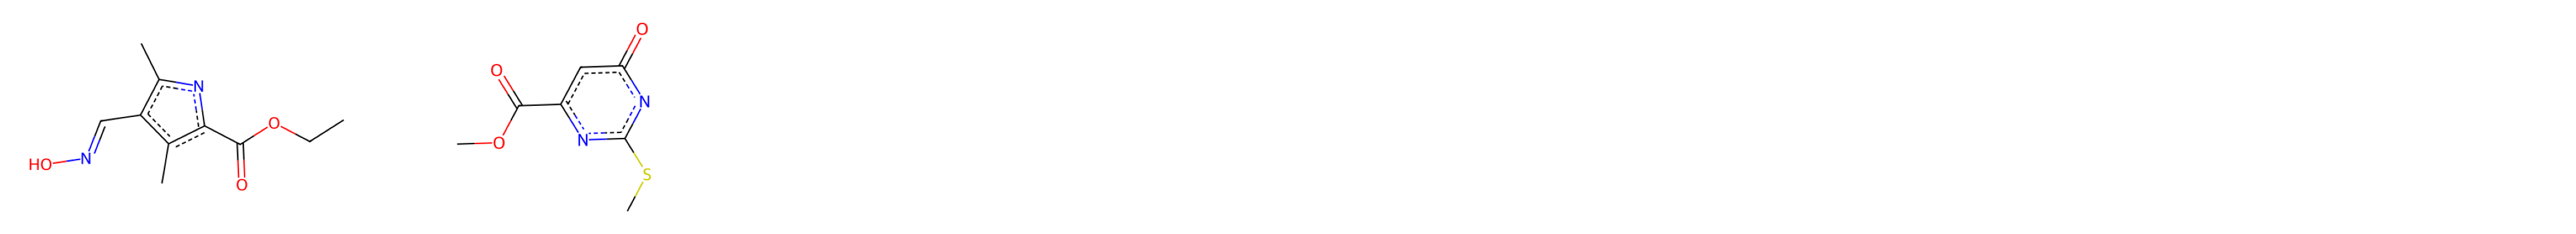

Trace seed index within seed_graphs = 0
Seed used for oracle phase trace


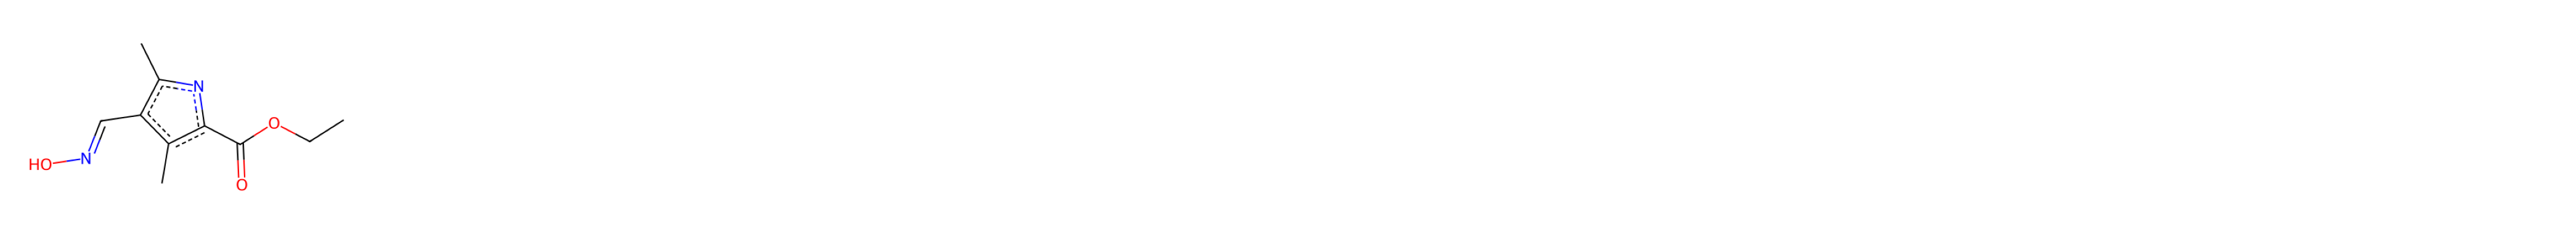

In [6]:
rng = np.random.default_rng()
seed_indices = rng.choice(len(graphs), size=N_SEEDS, replace=False)
seed_graphs = [graphs[int(idx)] for idx in seed_indices]
print('Selected seed indices:', seed_indices.tolist())
show_molecules(seed_graphs, n=N_SEEDS, title='Seed molecules for oracle study')
trace_seed_graph = seed_graphs[int(TRACE_SEED_INDEX)]
print('Trace seed index within seed_graphs =', int(TRACE_SEED_INDEX))
_ = show_molecules([trace_seed_graph], n=1, title='Seed used for oracle phase trace')


## Oracle Phase Trace

Decode one conditioning molecule with the oracle enabled so the per-iteration diagnostic panels show how accepted violating motifs accumulate across phases. Feasibility filtering is disabled in this trace cell to avoid rendering large candidate batches.


**Oracle strategy summary.** The decoder keeps structural edge-set cuts as the hard optimization mechanism. Node-label and edge-label changes are handled as soft follow-up repair proposals after each structural update, and a relabeling is accepted only if it improves the full oracle state rather than a label-only phase score.


Conditioning molecule


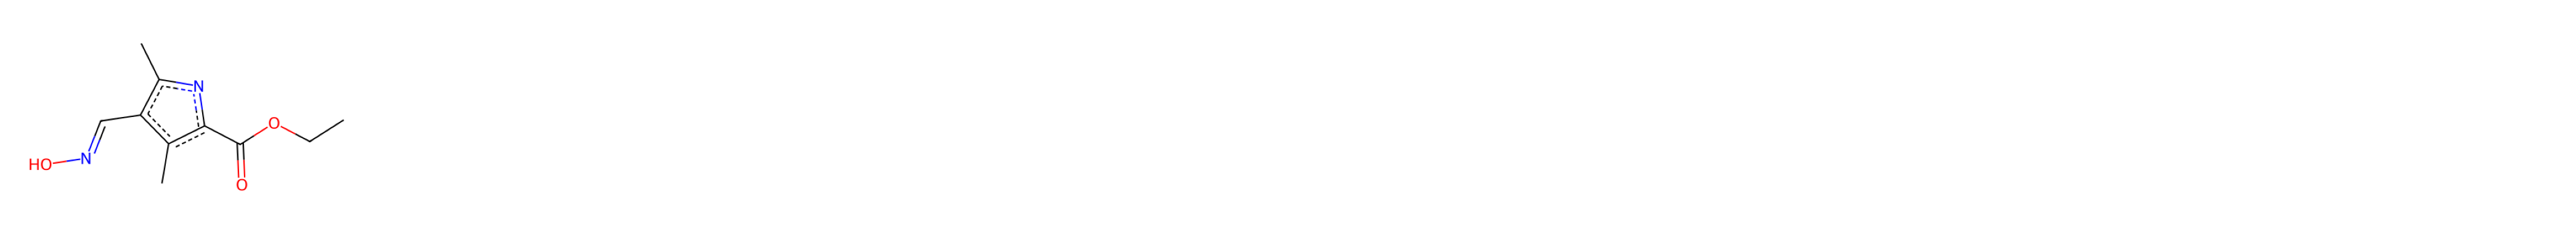

Oracle ON trace for the same conditioning graph (candidate budget=2, max_oracle_iterations=60).
Feasibility filtering is forced OFF here so only one decode trajectory is shown.
Rows are emitted separately for the joint-label phase, structural edge-set phase, and feasibility checks.
Node encoding 1 graphs
Class 'ConditionalNodeFieldGraphGenerator', Function 'node_encode' executed in 0.08 seconds (0.00 minutes, 0.00 hours).
Class 'ConditionalNodeFieldGraphGenerator', Function 'node_encode' executed in 0.08 seconds (0.00 minutes, 0.00 hours).
Encoding 1 graphs
Class 'ConditionalNodeFieldGraphGenerator', Function 'graph_encode' executed in 0.08 seconds (0.00 minutes, 0.00 hours).
Class 'ConditionalNodeFieldGraphGenerator', Function 'graph_encode' executed in 0.08 seconds (0.00 minutes, 0.00 hours).
Predicting node matrices for 1 graphs...
Generated graph 1/1: conditioning_nodes=15, conditioning_edges=15, raw_predicted_nodes=18, decoded_support_nodes=15, mean_degree=2.11, max_degree=3, mean

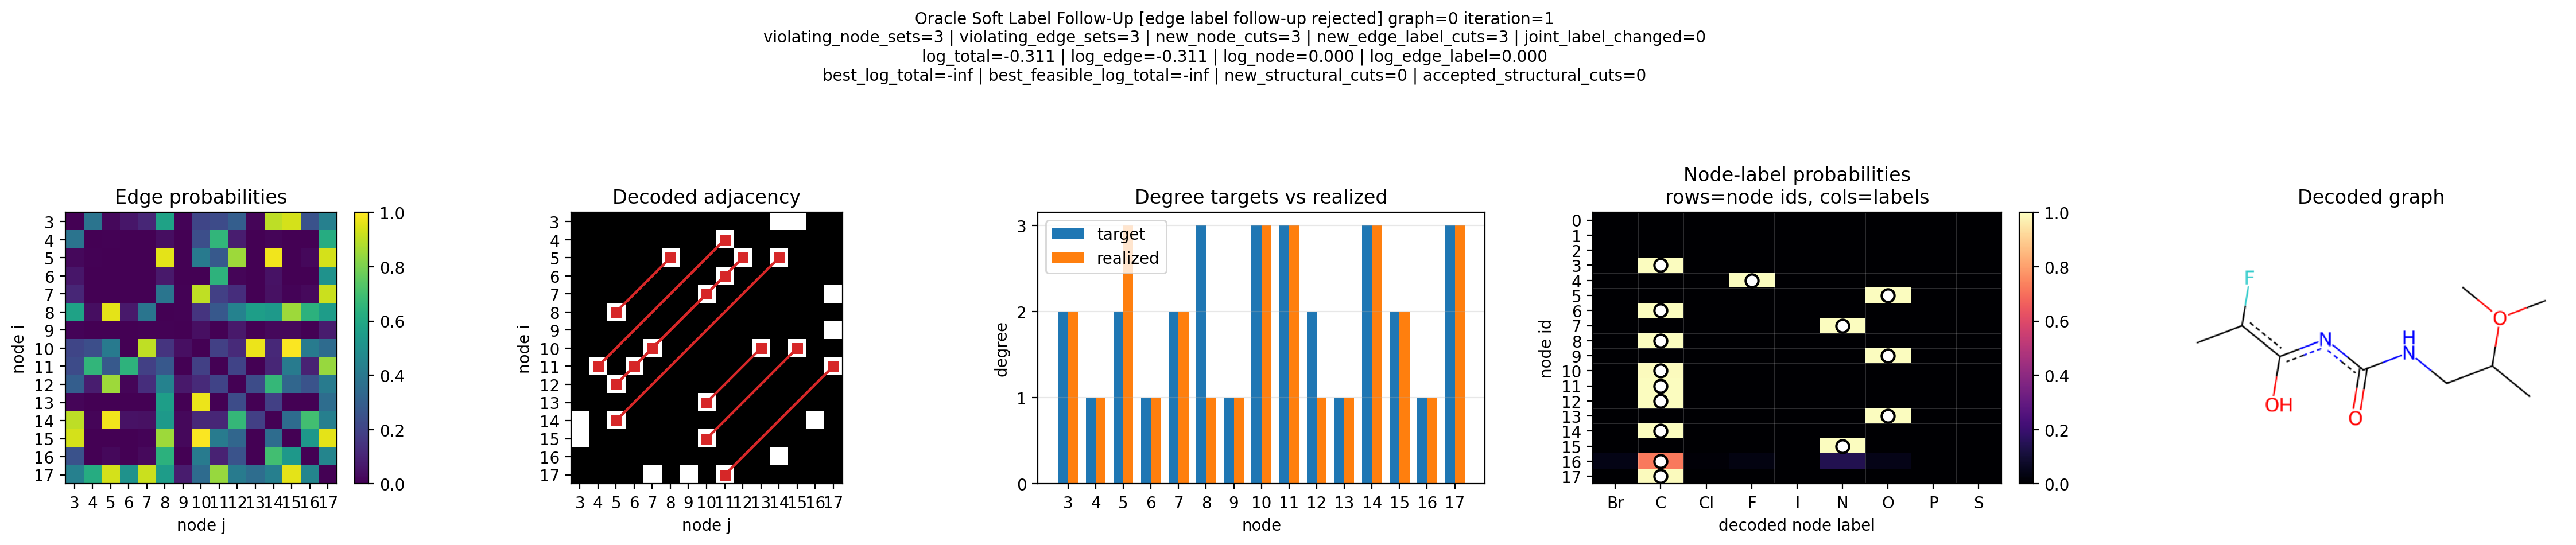

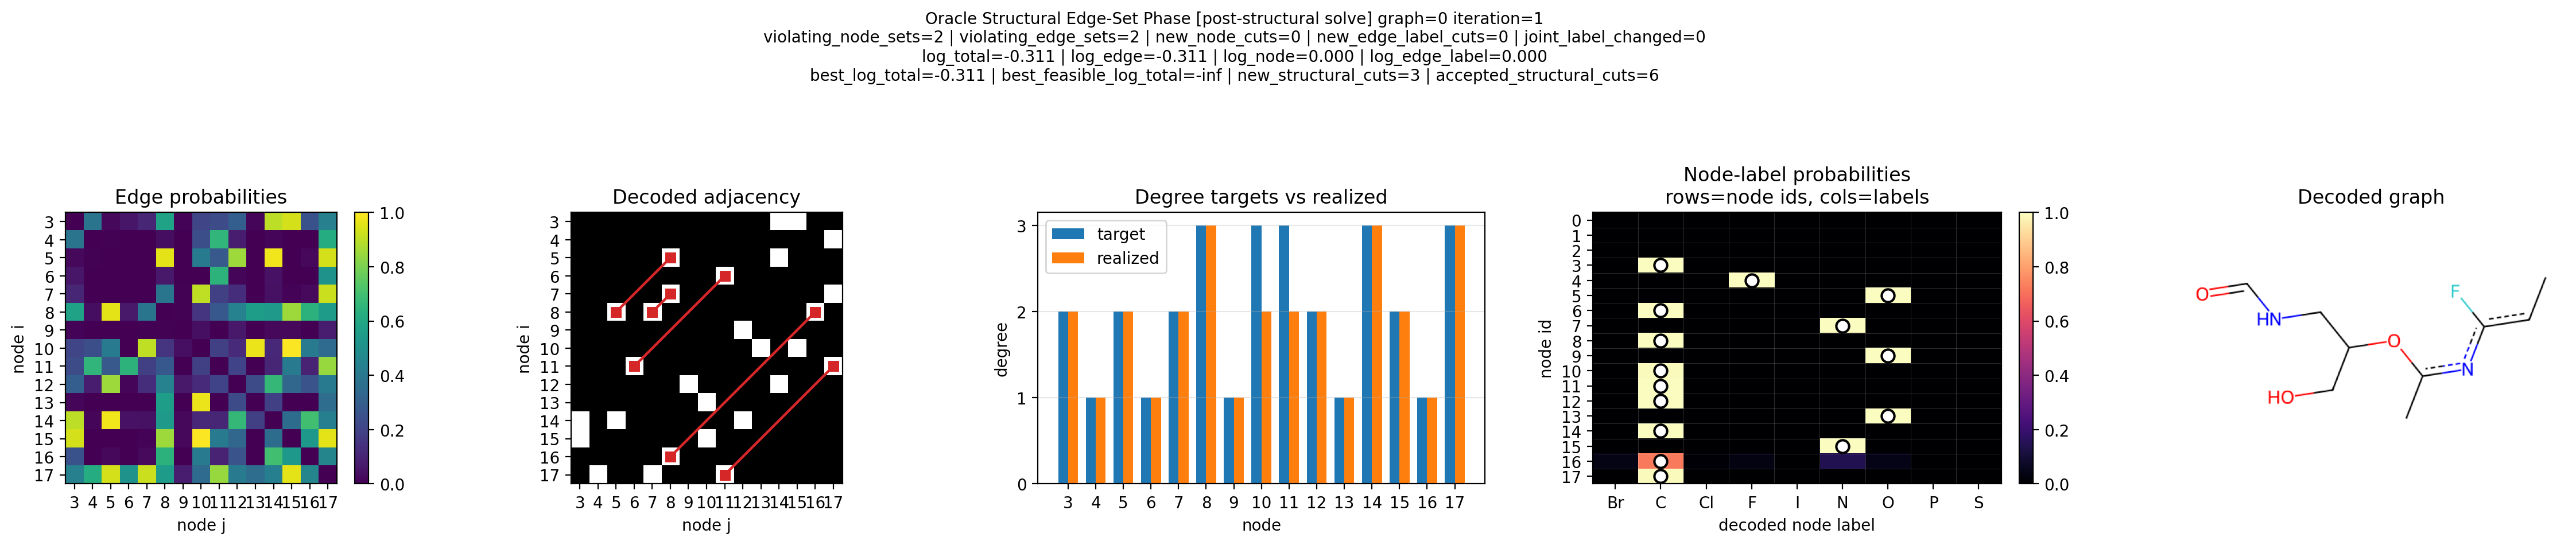

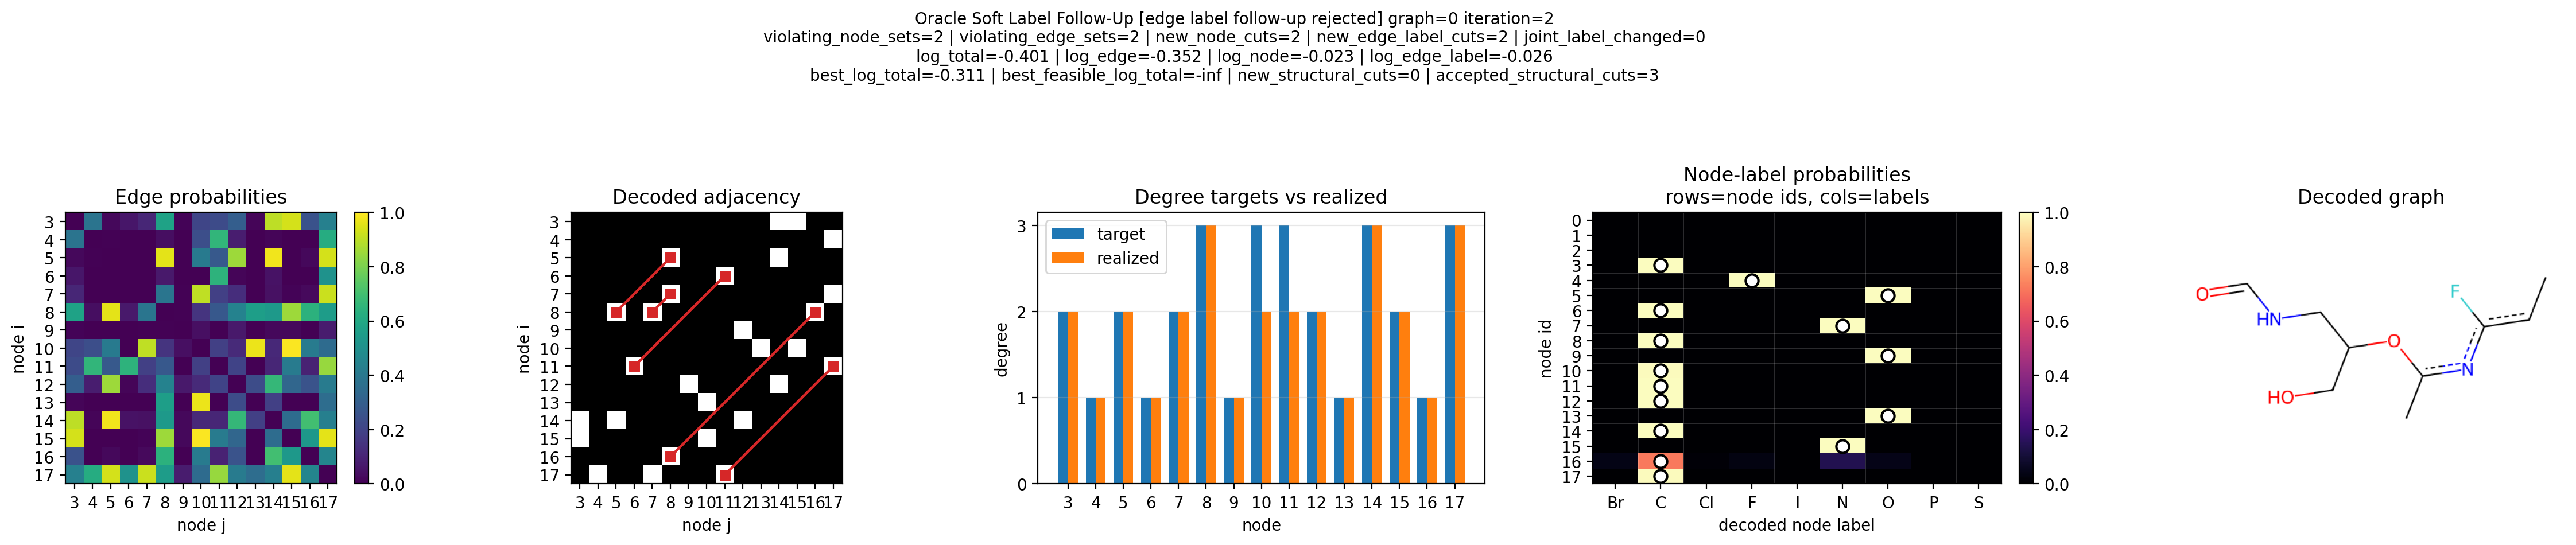

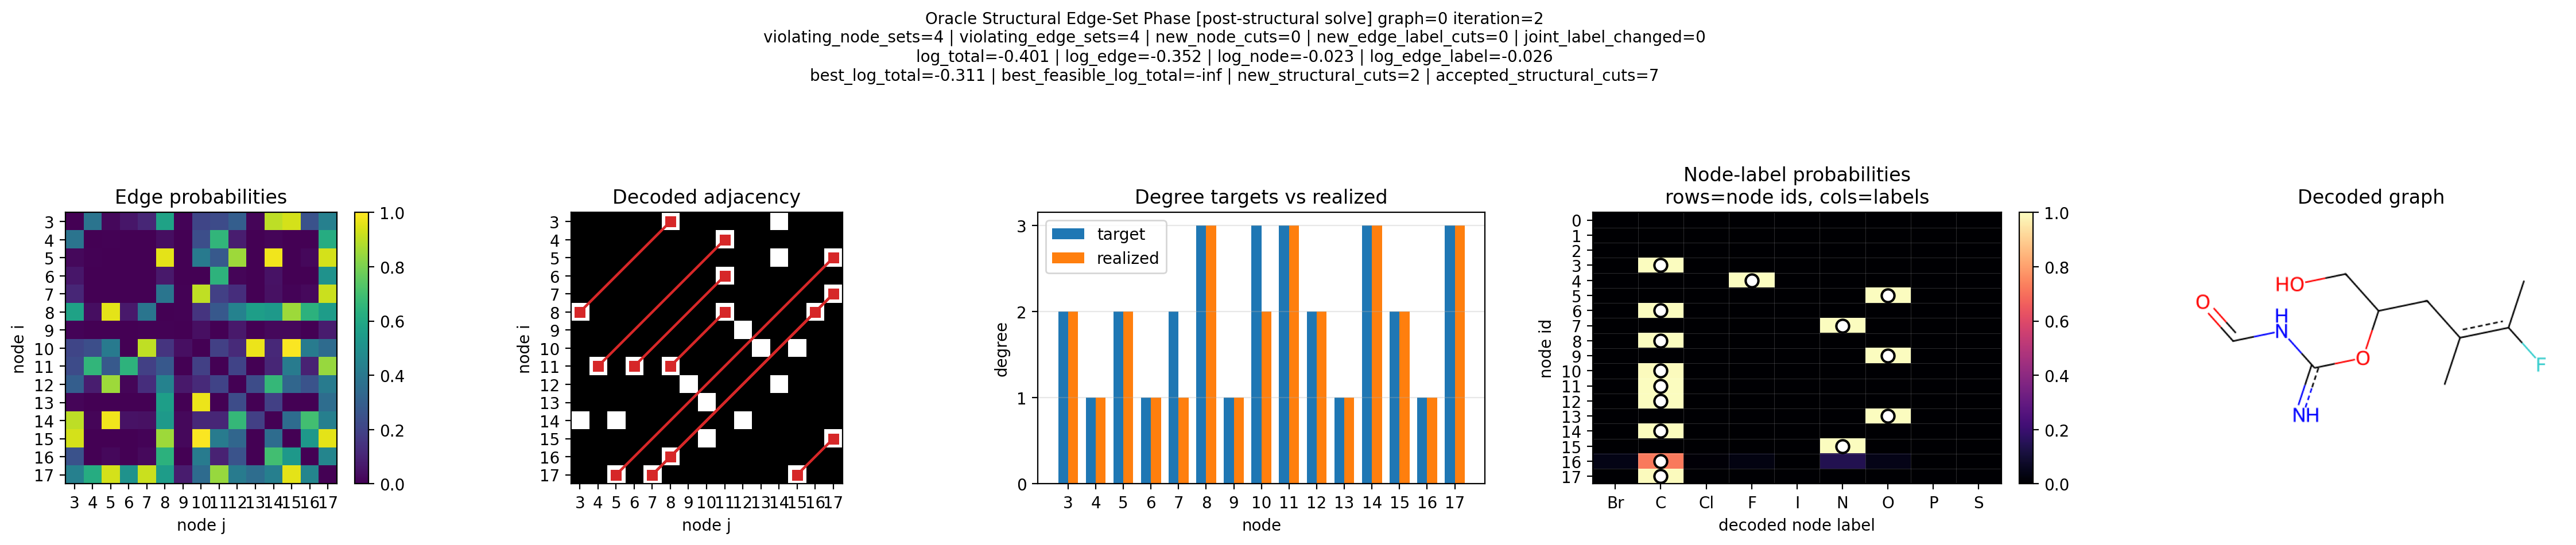

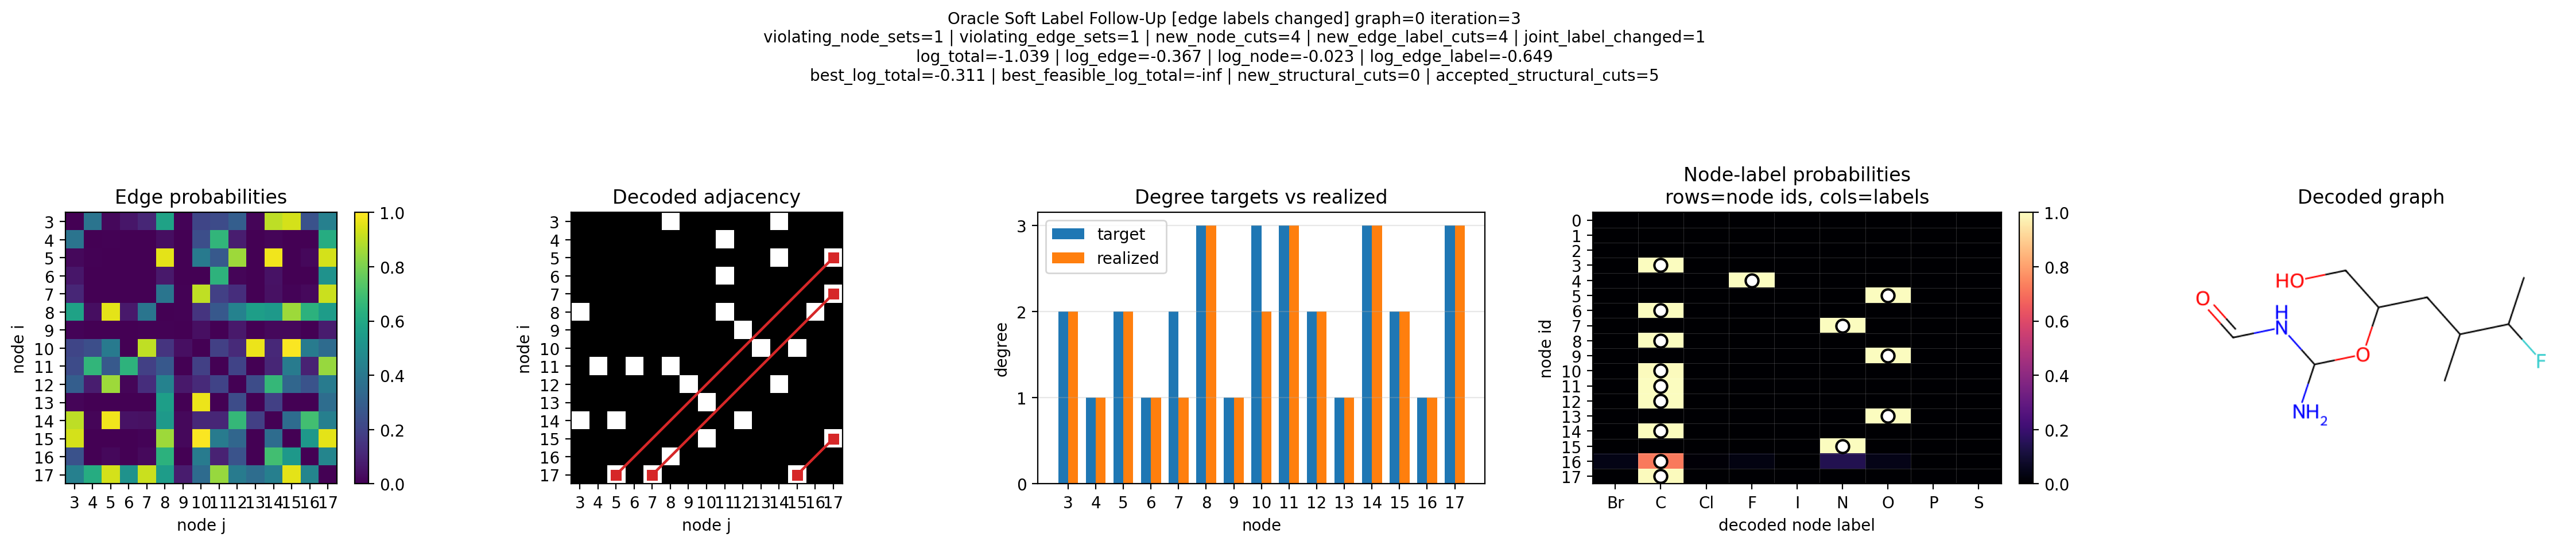

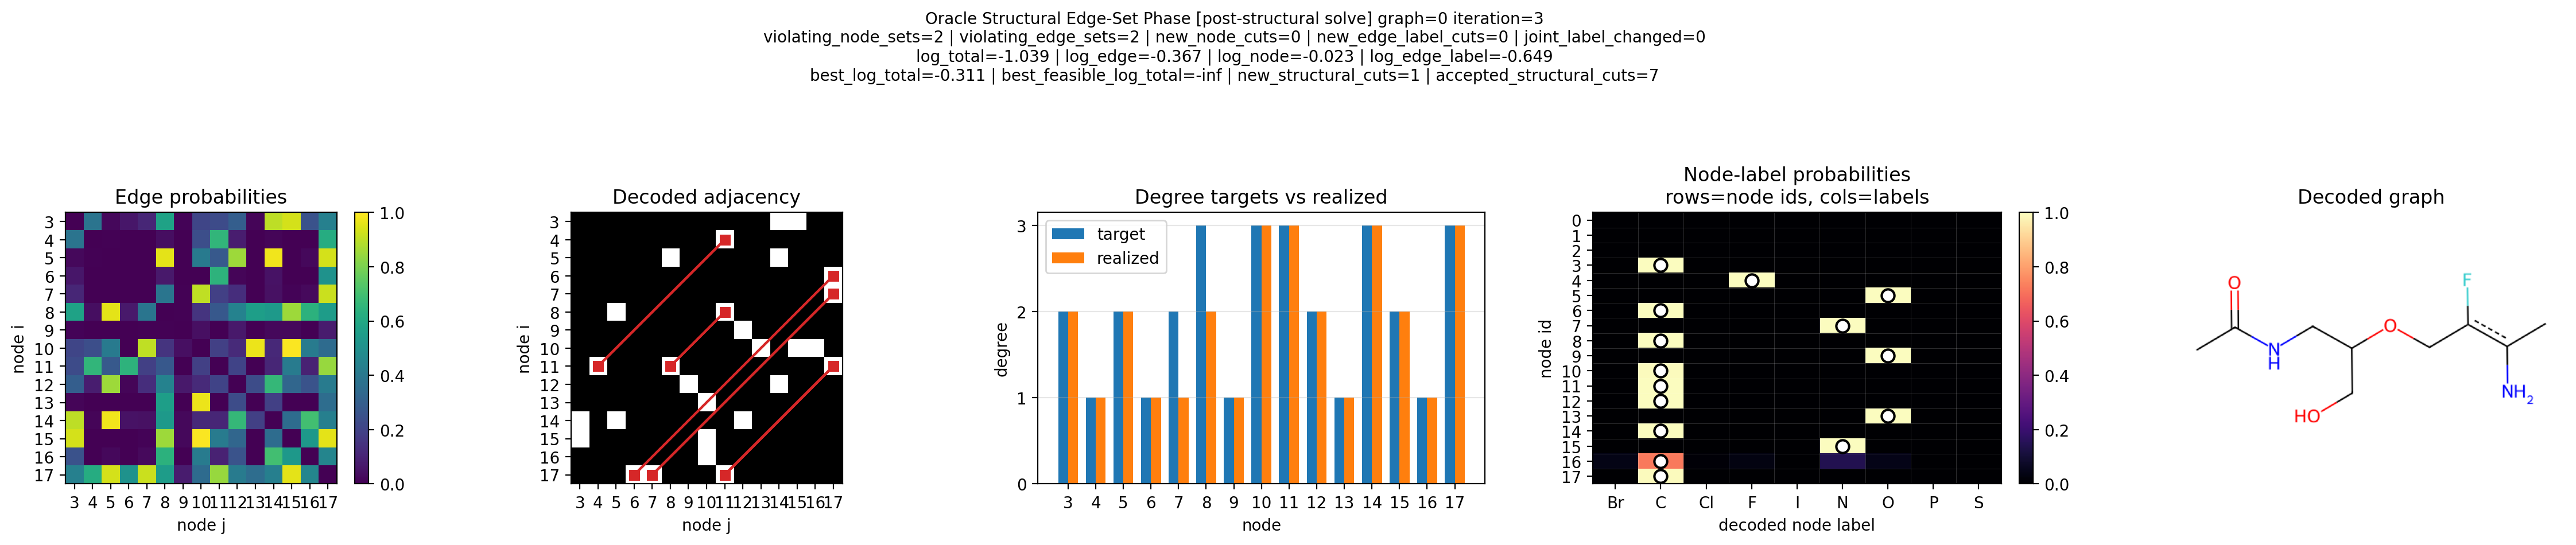

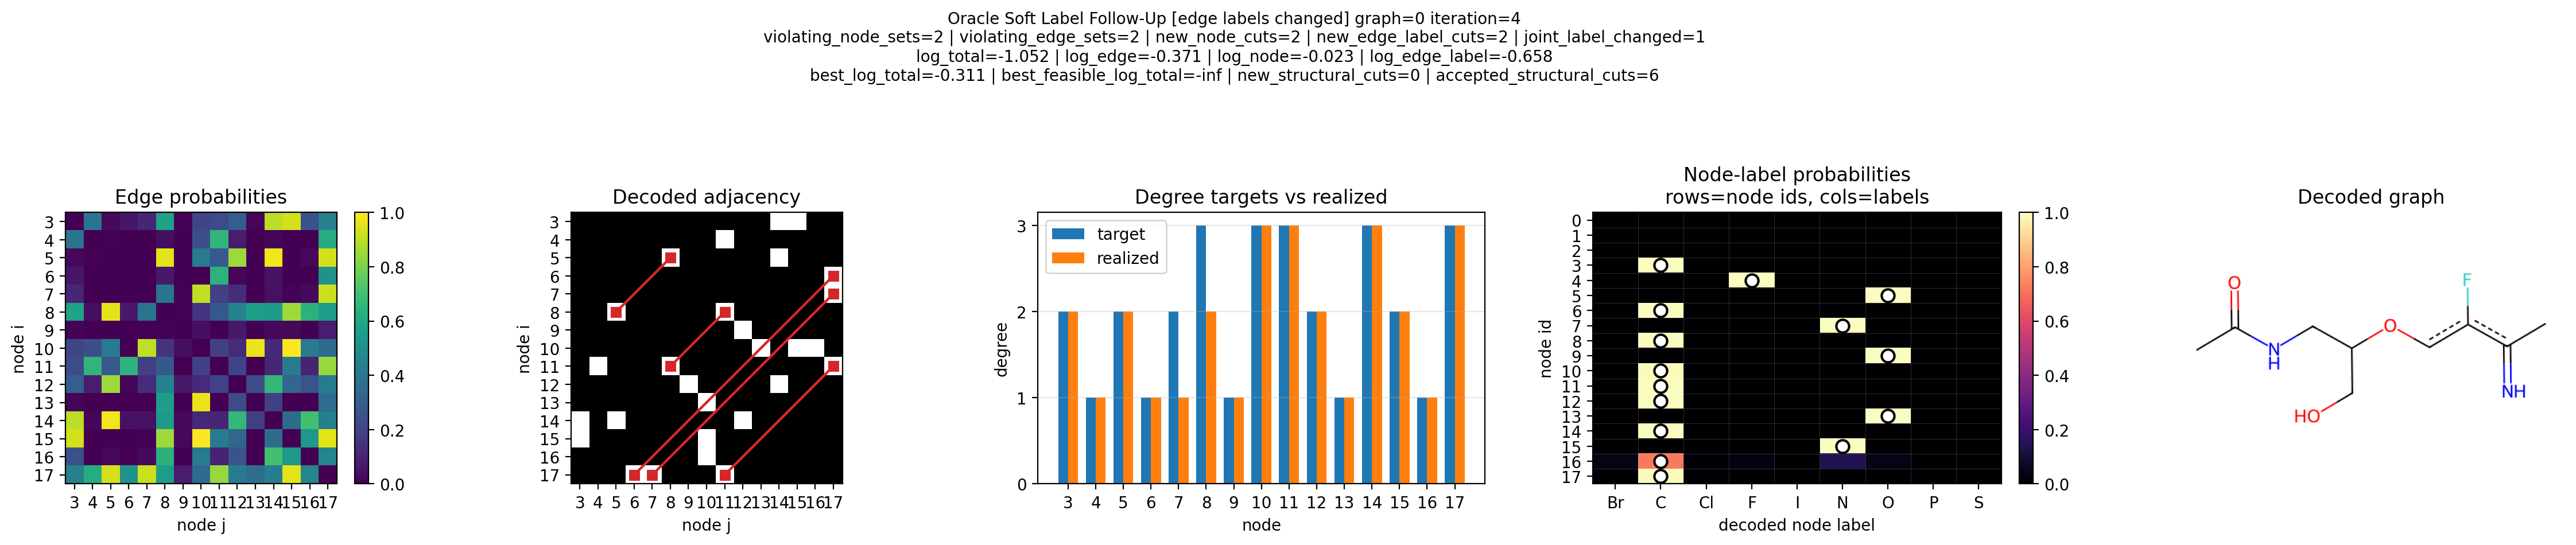

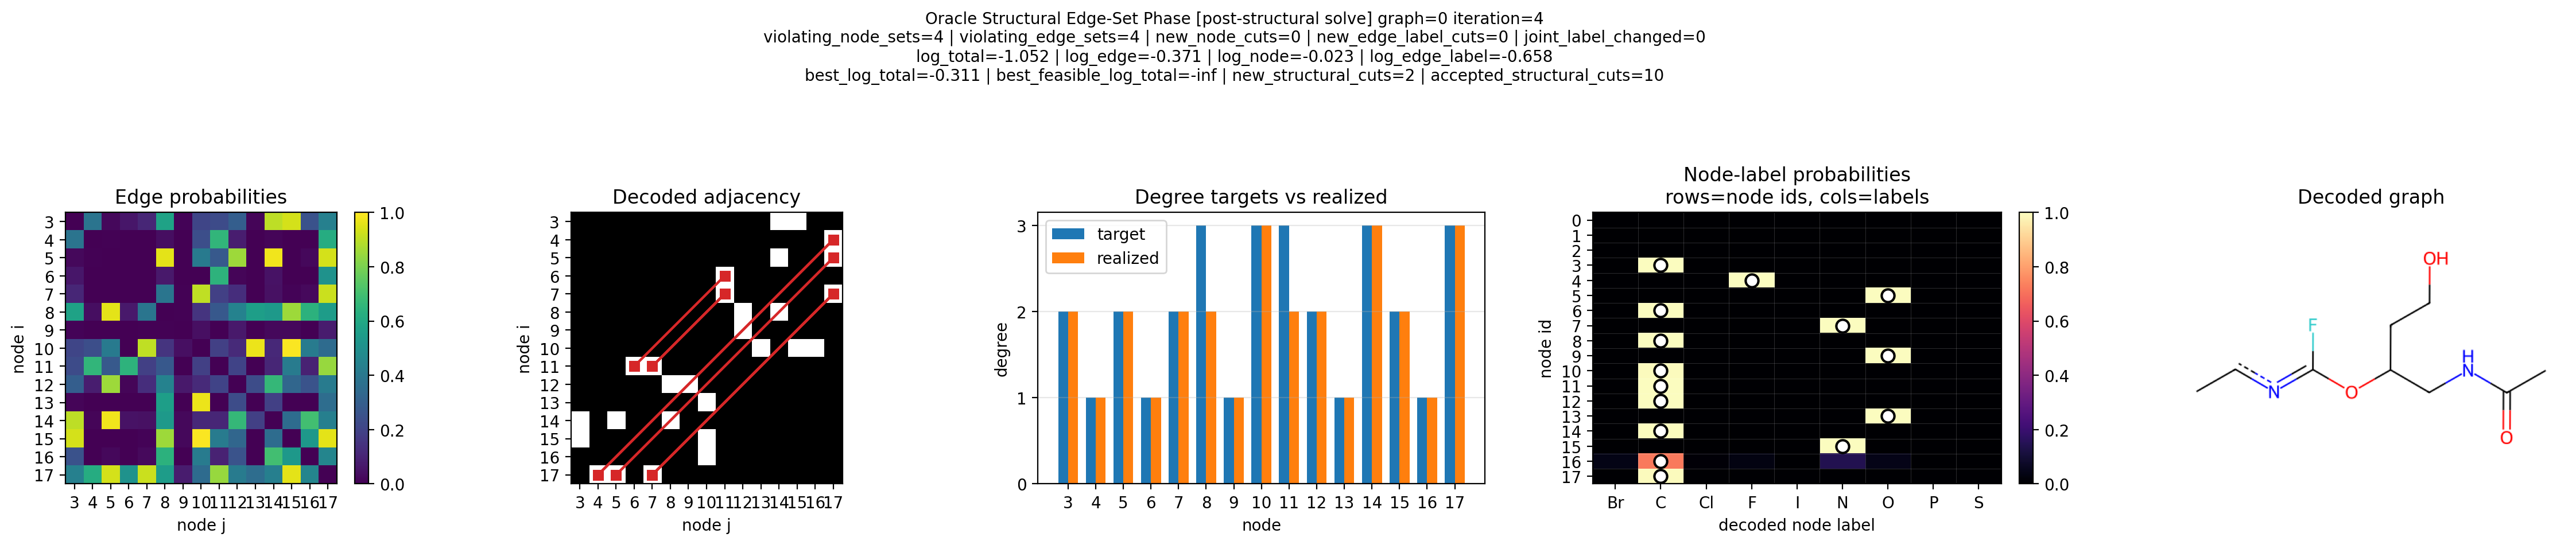

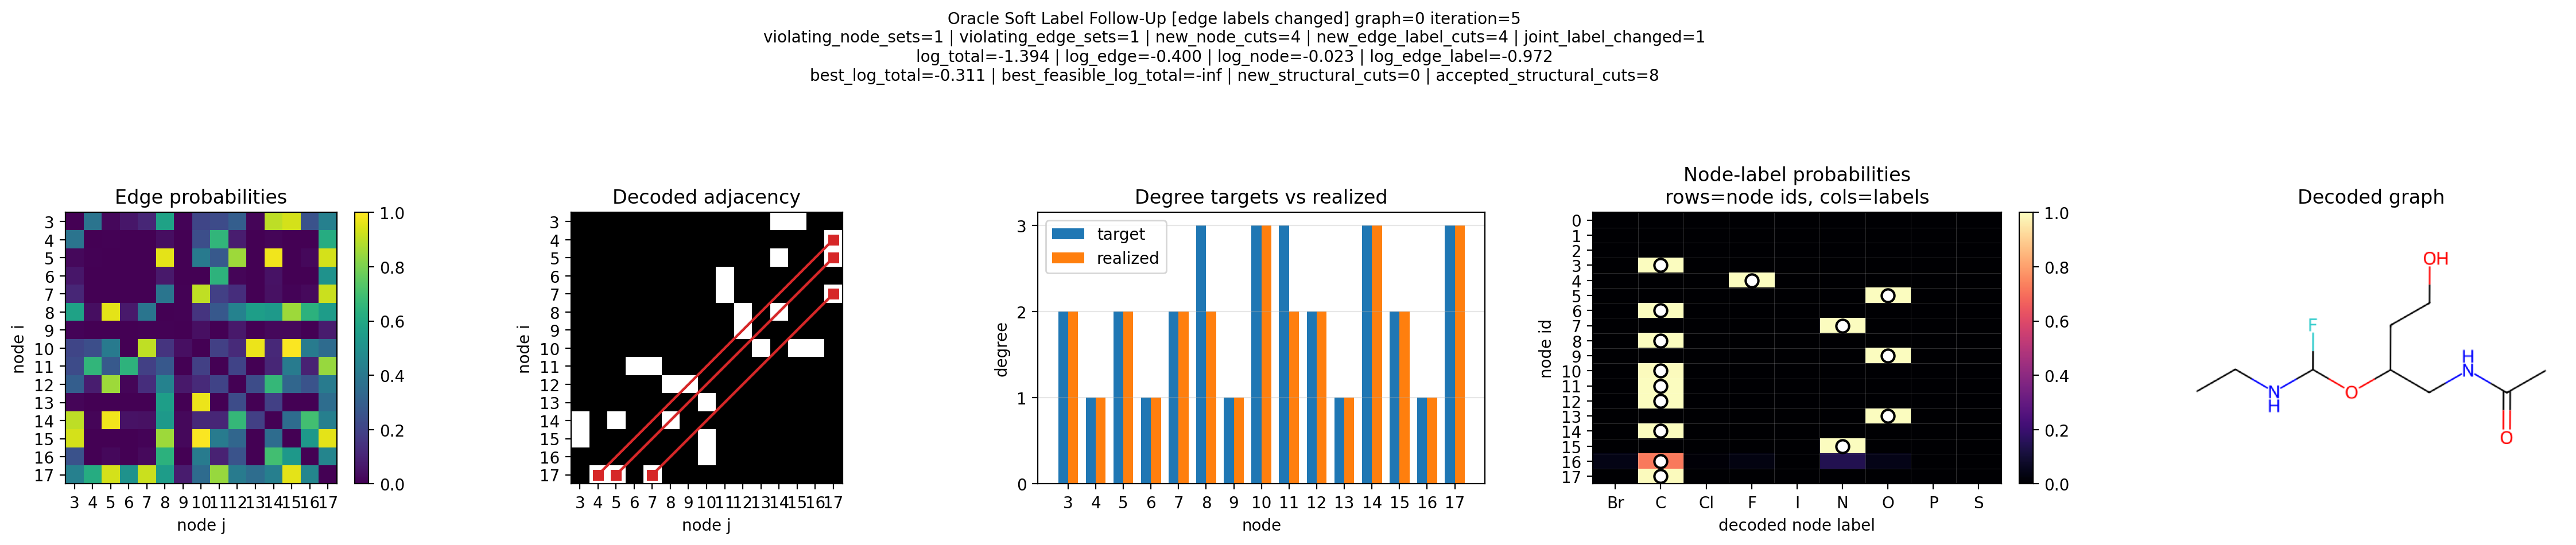

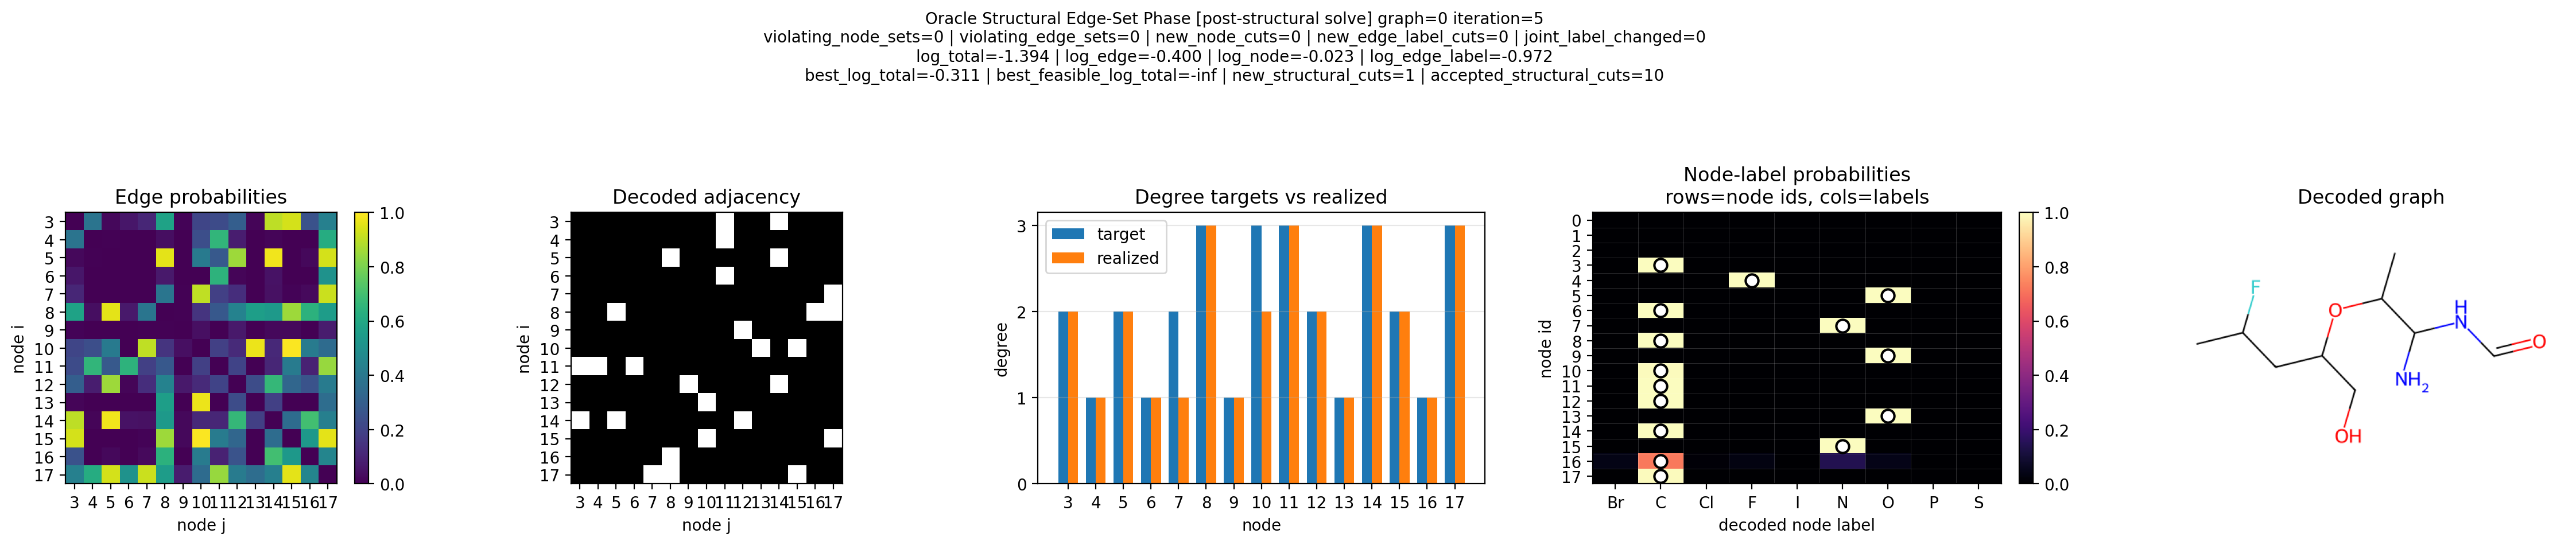

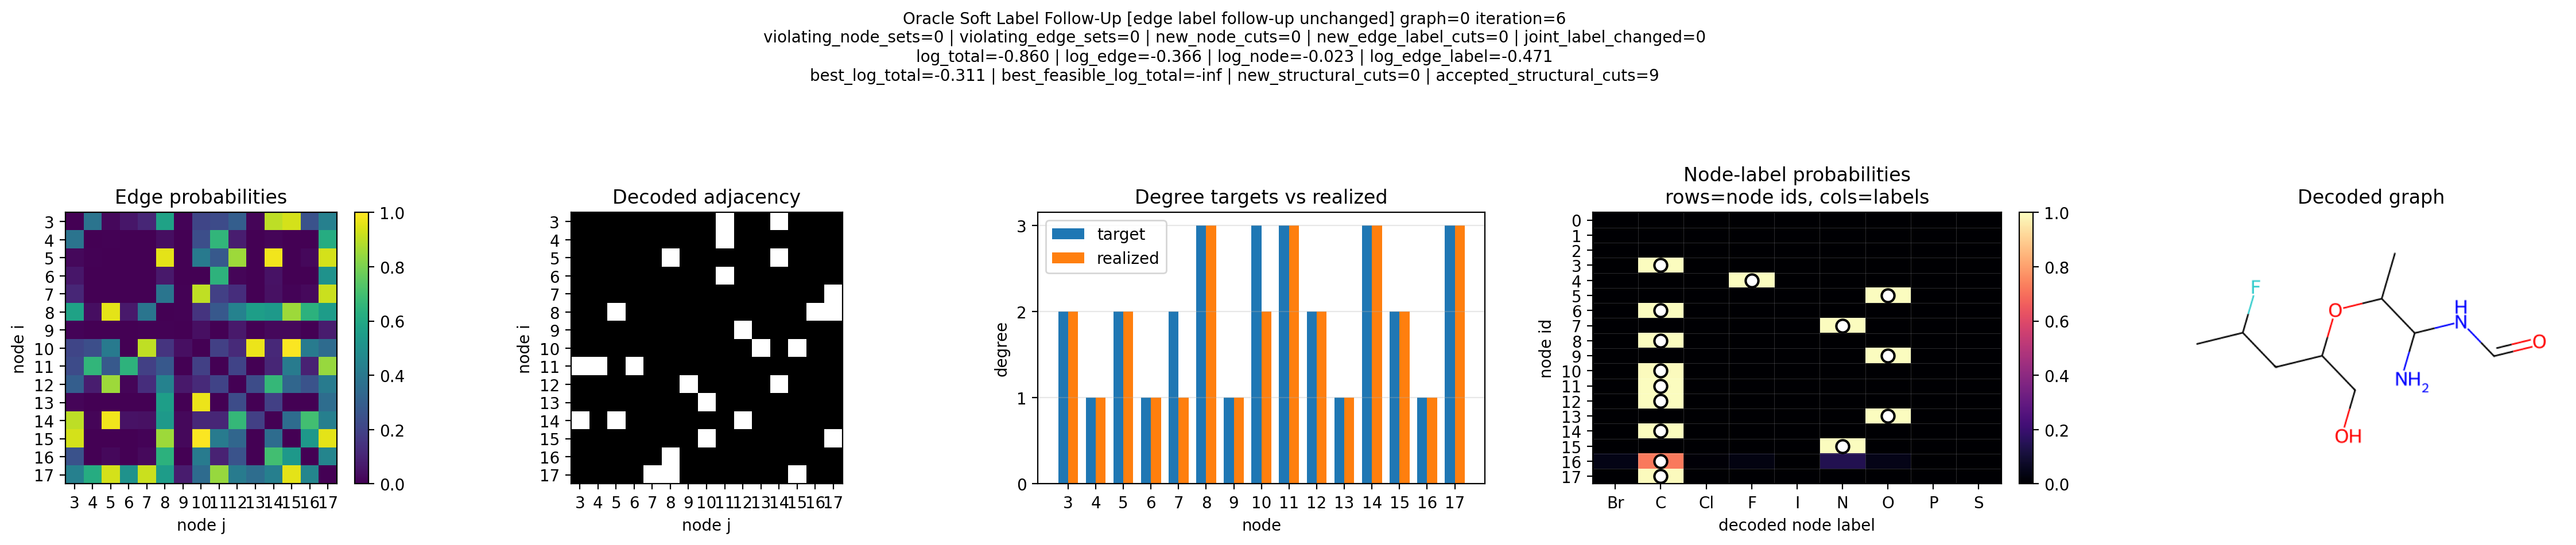

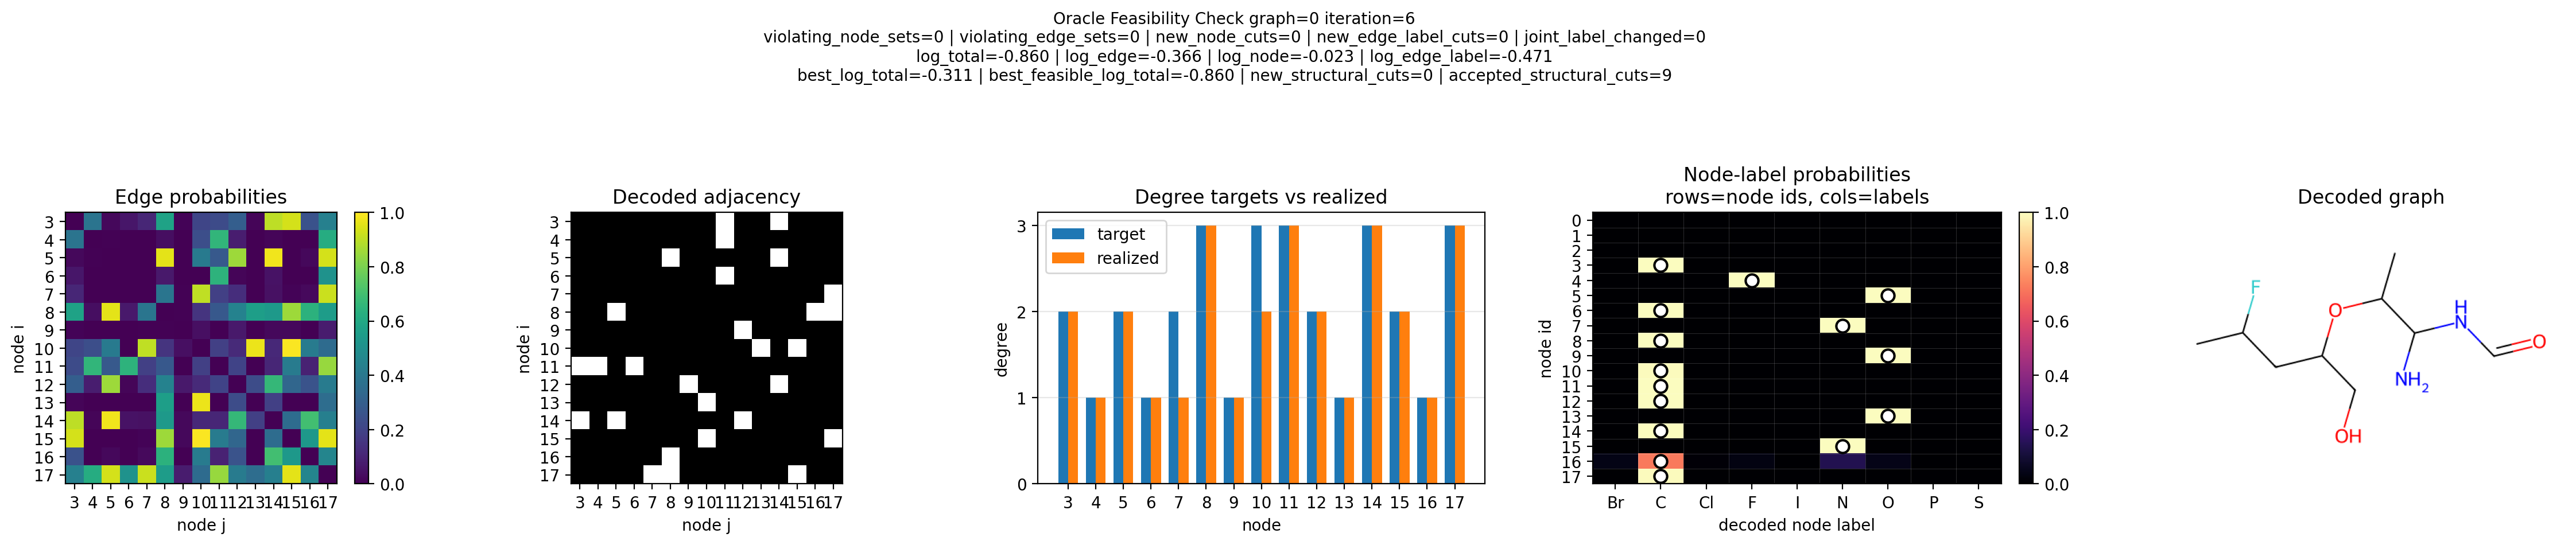

Class 'ConditionalNodeFieldGraphGenerator', Function 'conditional_sample' executed in 391.61 seconds (6.53 minutes, 0.11 hours).
Class 'ConditionalNodeFieldGraphGenerator', Function 'conditional_sample' executed in 391.61 seconds (6.53 minutes, 0.11 hours).
Oracle Soft Label Follow-Up [edge label follow-up rejected] iteration=1 violating_node_sets=3 violating_edge_sets=3 new_structural_cuts=0 accepted_structural_cuts=0
  proposal log-score: total=-0.311 | edge=-0.311 | node=0.000 | edge_label=0.000
  running best: best_total=-inf | best_feasible=-inf
Oracle Structural Edge-Set Phase [post-structural solve] iteration=1 violating_node_sets=2 violating_edge_sets=2 new_structural_cuts=3 accepted_structural_cuts=6
  proposal log-score: total=-0.311 | edge=-0.311 | node=0.000 | edge_label=0.000
  running best: best_total=-0.311 | best_feasible=-inf
Oracle Soft Label Follow-Up [edge label follow-up rejected] iteration=2 violating_node_sets=2 violating_edge_sets=2 new_structural_cuts=0 accepte

,phase,iteration,violating_node_sets,violating_edge_sets,new_structural_cuts,accepted_structural_cuts,log_total,log_edge,log_node,log_edge_label,best_log_total,best_feasible_log_total
0,Soft Label Follow-Up [edge label follow-up rej...,1,3,3,0,0,-0.311,-0.311,0.000,0.000,NaN,NaN
1,Structural Edge-Set Phase [post-structural solve],1,2,2,3,6,-0.311,-0.311,0.000,0.000,-0.311,NaN
2,Soft Label Follow-Up [edge label follow-up rej...,2,2,2,0,3,-0.401,-0.352,-0.023,-0.026,-0.311,NaN
3,Structural Edge-Set Phase [post-structural solve],2,4,4,2,7,-0.401,-0.352,-0.023,-0.026,-0.311,NaN
4,Soft Label Follow-Up [edge labels changed],3,1,1,0,5,-1.039,-0.367,-0.023,-0.649,-0.311,NaN
5,Structural Edge-Set Phase [post-structural solve],3,2,2,1,7,-1.039,-0.367,-0.023,-0.649,-0.311,NaN
6,Soft Label Follow-Up [edge labels changed],4,2,2,0,6,-1.052,-0.371,-0.023,-0.658,-0.311,NaN
7,Structural Edge-Set Phase [post-structural solve],4,4,4,2,10,-1.052,-0.371,-0.023,-0.658,-0.311,NaN
8,Soft Label Follow-Up [edge labels changed],5,1,1,0,8,-1.394,-0.400,-0.023,-0.972,-0.311,NaN
9,Structural Edge-Set Phase [post-structural solve],5,0,0,1,10,-1.394,-0.400,-0.023,-0.972,-0.311,NaN


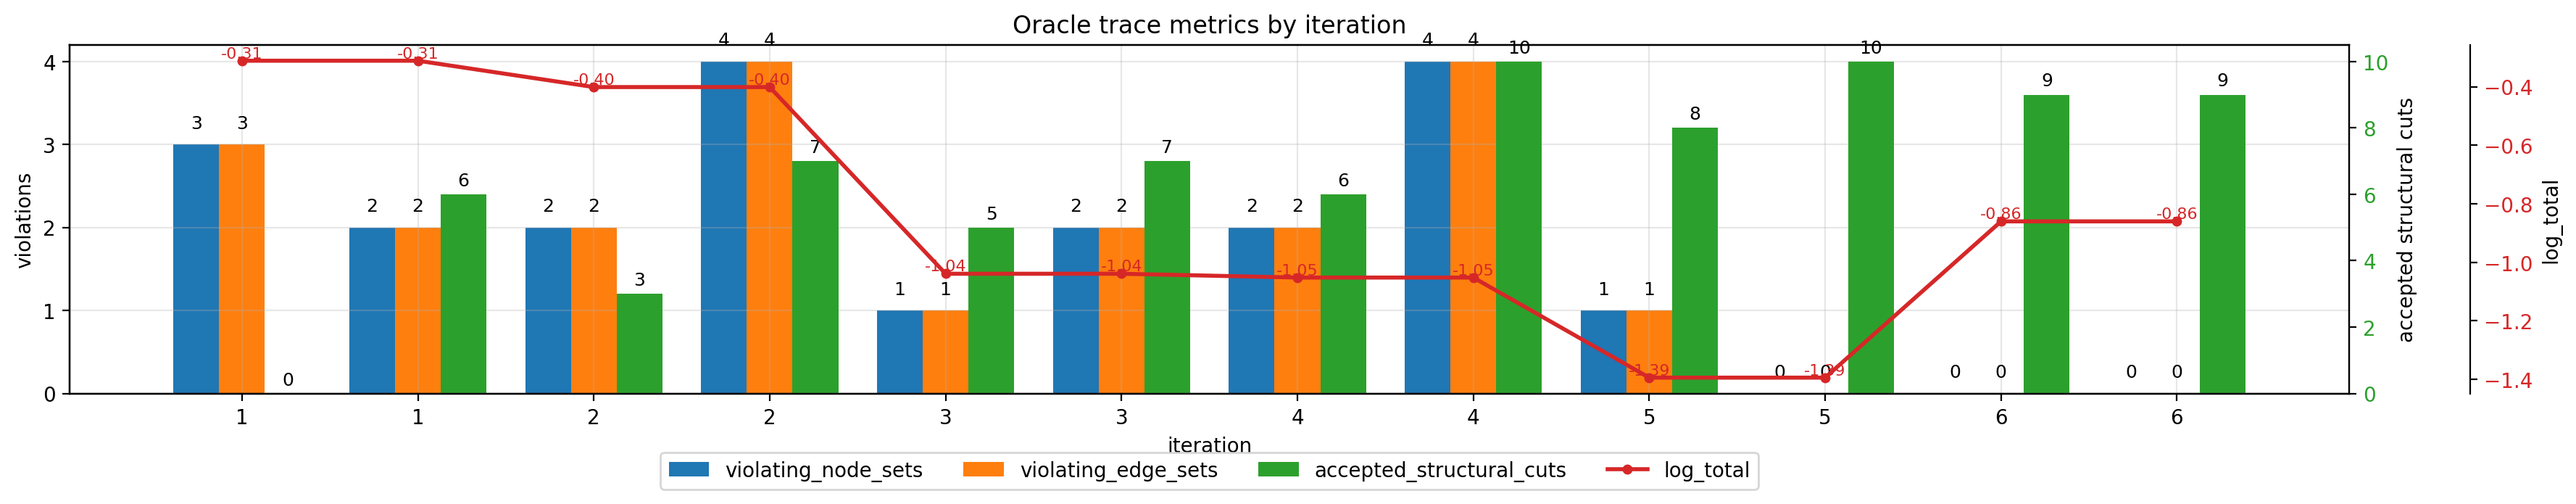

Final oracle-guided decoded sample


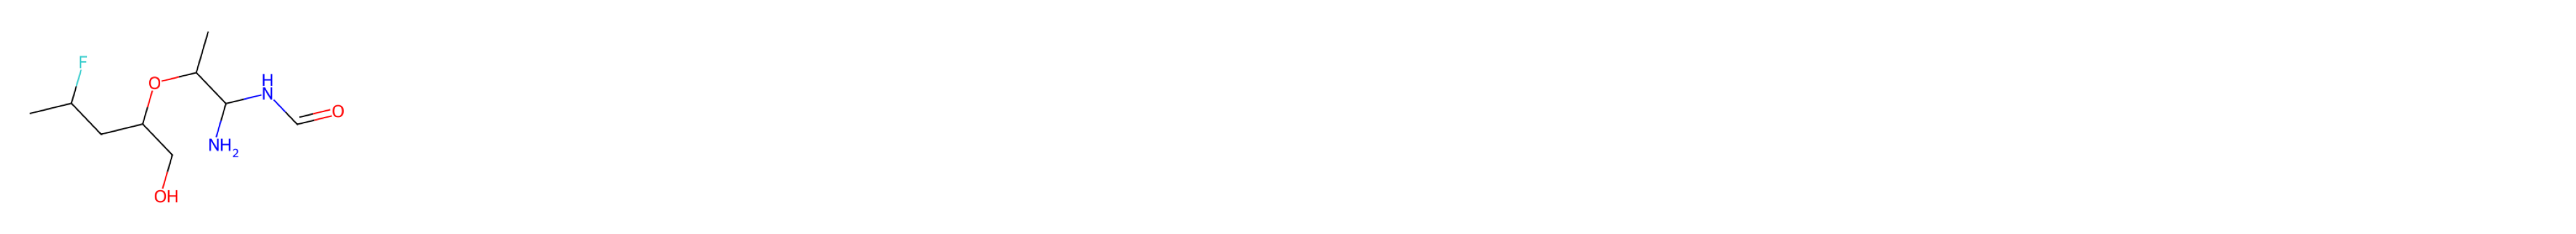

Seed used for oracle phase trace


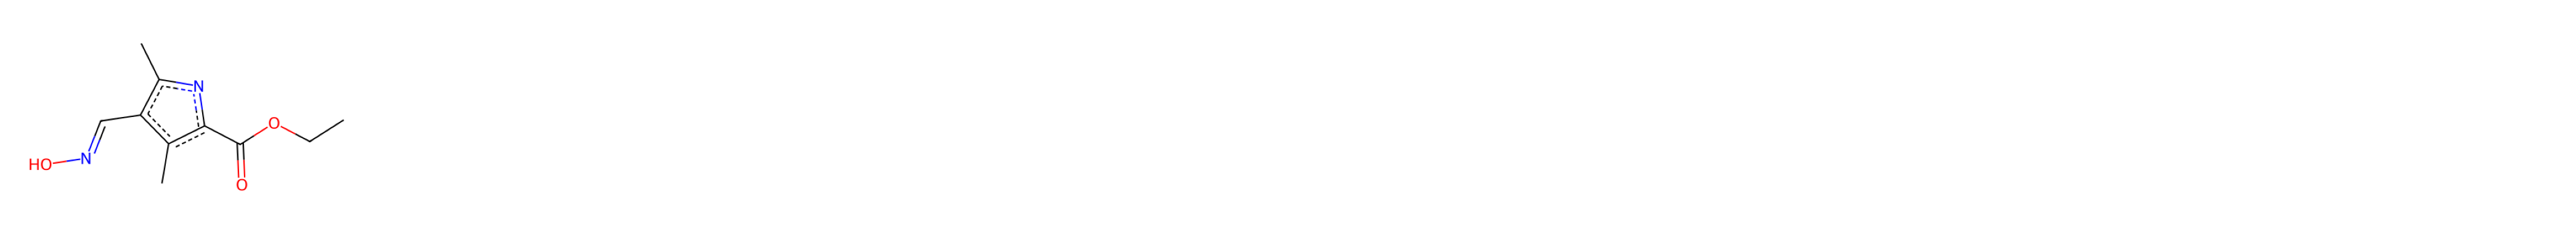

In [7]:
oracle_phase_trace = show_oracle_decode_trace(
    graph_generator,
    trace_seed_graph,
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
    seed=RANDOM_SEED,
)
_ = show_molecules([trace_seed_graph], n=1, title='Seed used for oracle phase trace')


## Feasible-Rate Score Comparison

Keep the retry budget fixed and compare how often the full decode pipeline yields feasible candidates with and without the oracle.


In [ ]:
oracle_score_comparison = compare_oracle_score(
    graph_generator,
    n_samples=N_SCORE_SAMPLES,
    max_feasibility_attempts=MAX_FEASIBILITY_ATTEMPTS,
    feasibility_candidates_per_attempt=FEASIBILITY_CANDIDATES_PER_ATTEMPT,
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
    seed=RANDOM_SEED + 1,
)


## Interpolation Comparison

Inspect whether the oracle changes which intermediate molecules successfully decode along the same interpolation path.


In [ ]:
endpoint_a, endpoint_b = seed_graphs[0], seed_graphs[1]
oracle_interpolation_comparison = compare_oracle_interpolation(
    graph_generator,
    endpoint_a,
    endpoint_b,
    k=5,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
)
